ADTA5560 Recurrent Neural Network Midterm
Question:
6.	PART IV: Simple RNN with Sine Wave Data and Keras (20 Points) 
TO-DO 
 
Build, train, and evaluate a simple recurrent neural network (a complete simple RNN) that has two layers: a SimpleRNN and a fully-connected layer in Keras. The SimpleRNN layer has 64 neurons. 
 
The training and testing the model are done on sine wave data belonging to a dataset generated by dividing the range 0 … 50 into 768 data points, including 0 and 50. All the tasks related to the project are done in Python using Jupyter Notebook. 

IMPORTANT NOTES: 
--) It is expected that the student knows how to count the layers of a deep neural network. 
 
--) First, draw a diagram to describe the architecture of the neural network with all the layers using MS PowerPoint or Draw Tool in MS Word. 
 
--) Build and train the model using the Keras sequential model in a Jupyter Notebook document. 
--) Run all the steps of the project in the Jupyter Notebook document to get the results of each step. 
 
 
 
IMPORTANT NOTES: 
--) It is expected that the student completes all the steps, including those related to data preprocessing. 
 
--) Evaluate the model on the test data. 
--) Write a report on these results. 


##  Importing Libraries

In [1]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# for timeseries RNN neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

2024-11-06 23:17:48.609042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-06 23:17:48.633814: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-06 23:17:48.641182: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-06 23:17:48.659515: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-06 23:17:49.919719: W tensorflow/compiler/tf2

In [3]:
# import keras: TimeseriesGenerator
# this class produces time series batches used on training/testing the model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# import keras: MinMax scalar
# this class is used to preprocess (scale) the data
from sklearn.preprocessing import MinMaxScaler

# Generate Data 

In [4]:
# create a simple sine wave in numpy

x = np.linspace(0,64,1024)
y = np.sin(x)


In [5]:
x

array([0.00000000e+00, 6.25610948e-02, 1.25122190e-01, ...,
       6.38748778e+01, 6.39374389e+01, 6.40000000e+01])

In [6]:
y

array([0.        , 0.06252029, 0.12479597, ..., 0.86393146, 0.89372716,
       0.92002604])

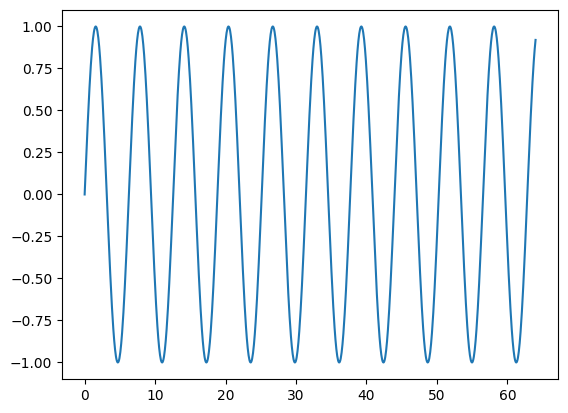

In [7]:
plt.plot(x, y)

In [8]:
# load data into a dataframe

df= pd.DataFrame(data=y, index=x, columns=['Sine'])
df.head(5)

,Sine
0.000000,0.000000
0.062561,0.062520
0.125122,0.124796
0.187683,0.186583
0.250244,0.247641


In [9]:
len(df)

1024

# Split train and test data

In [10]:
# set percentage of data used for testing

test_percent=0.2

In [11]:
# Number of data points reserved for tesing the model
# 20% of the original dataset

len(df)*test_percent

204.8

In [12]:
# need to find the length (number of data points) of the testing dataset
# It has been found (above) that around 205 data points are used for testing 

test_length = np.round(len(df)*test_percent)
test_length 

205.0

In [13]:
# The testing dataset  starts at this index
# Index starting with 0

test_start_index = int(len(df) - test_length)

In [14]:
test_start_index

819

In [15]:
# Create separate training / testing datasets

# Training dataset: All the indices from start to the test_start_index 
# ( excluding the test_start_index)

data_train = df.iloc[: test_start_index]

# Testing dataset: all the indices from the test_start_index to the end of the dataframe
# (including test_start_index)

data_test= df.iloc[test_start_index :]

data_train.head(5)


,Sine
0.000000,0.000000
0.062561,0.062520
0.125122,0.124796
0.187683,0.186583
0.250244,0.247641


In [16]:
data_test.head(5)


,Sine
51.237537,0.826045
51.300098,0.859666
51.362659,0.889923
51.425220,0.916698
51.487781,0.939887


## Normalize the data ( scale it into [0,1])

In [17]:
# Create a MinMaxScalar to normalize the data
scalar = MinMaxScaler()

In [18]:
# IGNORE the warning: Just converting the data to floats
# Only Scale the Trainig data  - Not scale the testing data
# train the sccalar to perform the normalization

scalar.fit(data_train)

MinMaxScaler()

In [19]:
# Normalize the training dataset
normalized_train= scalar.transform(data_train)

# Normalize the testing dataset
normalized_train= scalar.transform(data_test)

# Create timeseries generator instance

In [20]:
#from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Set the length of the input sequence
# i.e., the number of time series steps used to predict the next one
# Use 50 historical data points to predict the next one
length = 50

# Set the batch size
# Number of time series samples in each batch
# Only one sample in each batch
batch_size = 1

# Create a TimeSeriesGenerator for training
# This time series generator produces time series batches used to train the model
# TimeseriesGenerator(inputs dataset, outputs dataset, length, batch_size)
train_tsGenerator50 = TimeseriesGenerator(normalized_train, normalized_train, length=length, batch_size=batch_size)

# Get the length of the normalized training data
len(normalized_train)


205

In [21]:
# first batch
X,y=train_tsGenerator50[0]


In [22]:
X.flatten()

array([0.91302295, 0.92983336, 0.94496198, 0.95834964, 0.96994395,
       0.97969954, 0.98757825, 0.99354925, 0.99758917, 0.99968222,
       0.9998202 , 0.99800257, 0.99423644, 0.98853656, 0.98092521,
       0.97143218, 0.96009462, 0.94695688, 0.93207036, 0.91549332,
       0.89729061, 0.87753344, 0.85629913, 0.83367076, 0.80973685,
       0.78459106, 0.75833177, 0.73106172, 0.70288761, 0.67391968,
       0.64427126, 0.61405835, 0.58339918, 0.5524137 , 0.52122313,
       0.48994952, 0.45871523, 0.42764247, 0.39685281, 0.36646672,
       0.33660309, 0.30737877, 0.27890809, 0.25130246, 0.22466988,
       0.19911455, 0.17473647, 0.15163101, 0.12988859, 0.10959426])

In [23]:
y

array([[0.09082743]])

## Build Train and Test Model

# Build simple RNN Model

In [ ]:
# Data set: Only one column/attribute: Sine values of index x
# Features: How many features used to train the model: Only one
n_features = 1

# define model
model = Sequential()

# Add a simple RNN layer: Using SimpleRNN cells
# This layer has 100 neurons: One neuron for each input data point
# NOTES: # time series steps of the input sequence: 50
model.add(SimpleRNN(64, input_shape=(length, n_features)))

# Add a FC (fully-connected) layer for the final prediction
# Only one neuron of the Dense/Fully-Connected layer
# --> Output: Predict the next data point of the input sequence: only one value
model.add(Dense(1))


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# complie model

In [25]:
# complie the model

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,301 (40.24 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

# Train (Fit) Model

In [41]:
# Fit the model
# Use fit_generator(), Not fit()

#model.fit_generator(train_tsGenerator50, epochs=5)
model.fit(train_tsGenerator50,epochs=5 )


Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0023
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5598e-04
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0225e-04
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2502e-04
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.8293e-05


# Visualize Model's Porformance After Training  

<Axes: >

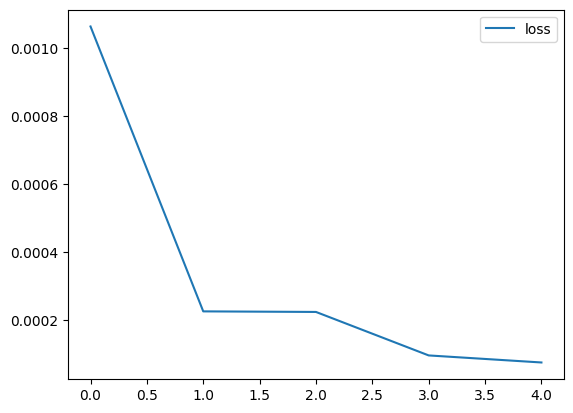

In [42]:
# load the loss data into a dataframe

df_model_loss = pd.DataFrame(model.history.history)

# visualize the loss data using Dataframe.plot()
df_model_loss.plot()


# Evaluate Model on Test Data

# A sneakpeak into the test data

In [43]:
length

50

In [44]:
first_eval_batch = normalized_train[-length : ]
first_eval_batch


array([[2.64197896e-02],
       [1.73186625e-02],
       [1.01060768e-02],
       [4.81025227e-03],
       [1.45190959e-03],
       [4.41886080e-05],
       [5.92597207e-04],
       [3.09498967e-03],
       [7.54157510e-03],
       [1.39149557e-02],
       [2.21901950e-02],
       [3.23349150e-02],
       [4.43094235e-02],
       [5.80668687e-02],
       [7.35534232e-02],
       [9.07084940e-02],
       [1.09464960e-01],
       [1.29749434e-01],
       [1.51482551e-01],
       [1.74579278e-01],
       [1.98949246e-01],
       [2.24497105e-01],
       [2.51122896e-01],
       [2.78722442e-01],
       [3.07187757e-01],
       [3.36407468e-01],
       [3.66267248e-01],
       [3.96650268e-01],
       [4.27437652e-01],
       [4.58508939e-01],
       [4.89742560e-01],
       [5.21016310e-01],
       [5.52207827e-01],
       [5.83195070e-01],
       [6.13856798e-01],
       [6.44073043e-01],
       [6.73725582e-01],
       [7.02698395e-01],
       [7.30878123e-01],
       [7.58154509e-01],


In [45]:
first_eval_batch=first_eval_batch.reshape((1,length,n_features))

first_eval_batch

array([[[2.64197896e-02],
        [1.73186625e-02],
        [1.01060768e-02],
        [4.81025227e-03],
        [1.45190959e-03],
        [4.41886080e-05],
        [5.92597207e-04],
        [3.09498967e-03],
        [7.54157510e-03],
        [1.39149557e-02],
        [2.21901950e-02],
        [3.23349150e-02],
        [4.43094235e-02],
        [5.80668687e-02],
        [7.35534232e-02],
        [9.07084940e-02],
        [1.09464960e-01],
        [1.29749434e-01],
        [1.51482551e-01],
        [1.74579278e-01],
        [1.98949246e-01],
        [2.24497105e-01],
        [2.51122896e-01],
        [2.78722442e-01],
        [3.07187757e-01],
        [3.36407468e-01],
        [3.66267248e-01],
        [3.96650268e-01],
        [4.27437652e-01],
        [4.58508939e-01],
        [4.89742560e-01],
        [5.21016310e-01],
        [5.52207827e-01],
        [5.83195070e-01],
        [6.13856798e-01],
        [6.44073043e-01],
        [6.73725582e-01],
        [7.02698395e-01],
        [7.3

In [46]:
first_eval_batch.shape


(1, 50, 1)

# Evaluate Model

In [47]:
# ALL the code for evaluation

# Declare a list to store all the predictions
# Similar to: test_predictions = list()
test_predictions = []

# Get the first time series batch for testing
# The 1st batch: The 1st time series input sequence
# = The last 50 data points of the train data set
first_eval_batch = normalized_train[-length:]

# Reshape the batch into 3D array: #samples/batch x Length x #features
current_batch = first_eval_batch.reshape((1, length, n_features))

# Run a FOR loop to make a prediction for each batch
for i in range(len(data_test)):

    # Get the value of the first element: The prediction
    current_pred = model.predict(current_batch)[0]

    # Store prediction into the list of predictions
    test_predictions.append(current_pred)

    # Generate a new batch to prepare for the next iteration of testing
    # --> Drop the first data point of the current input sequence
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

In [48]:
# convert the scaled result back to the real values
true_predictions= scalar.inverse_transform(test_predictions)

true_predictions

array([[ 0.86245048],
       [ 0.87378402],
       [ 0.83198058],
       [ 0.8018422 ],
       [ 0.75697521],
       [ 0.70423566],
       [ 0.6552661 ],
       [ 0.58120534],
       [ 0.51800868],
       [ 0.43266826],
       [ 0.36244209],
       [ 0.27033382],
       [ 0.18689979],
       [ 0.09942779],
       [ 0.0032886 ],
       [-0.08088232],
       [-0.19528372],
       [-0.28248982],
       [-0.38774622],
       [-0.48744261],
       [-0.59536625],
       [-0.7040486 ],
       [-0.79936969],
       [-0.91699038],
       [-1.00075462],
       [-1.11791261],
       [-1.19717602],
       [-1.29864203],
       [-1.37856798],
       [-1.45223294],
       [-1.51953206],
       [-1.56422554],
       [-1.61375157],
       [-1.62029018],
       [-1.64435135],
       [-1.61279719],
       [-1.60254517],
       [-1.54282052],
       [-1.47157494],
       [-1.39432278],
       [-1.27217516],
       [-1.16731061],
       [-1.00517498],
       [-0.87035574],
       [-0.68224047],
       [-0

In [49]:
data_test

,Sine,Predictions
51.237537,0.826045,1.042377
51.300098,0.859666,1.065349
51.362659,0.889923,1.139525
51.425220,0.916698,1.185049
51.487781,0.939887,1.235116
...,...,...
63.749756,0.794329,1.564107
63.812317,0.830756,1.564105
63.874878,0.863931,1.564108
63.937439,0.893727,1.564107


In [50]:
# Copy the true values of predictions into the dataframe of original test data
# Add it as another column

data_test['Predictions'] = true_predictions

/var/tmp/ipykernel_10618/1664254025.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test['Predictions'] = true_predictions


In [51]:
data_test

,Sine,Predictions
51.237537,0.826045,0.862450
51.300098,0.859666,0.873784
51.362659,0.889923,0.831981
51.425220,0.916698,0.801842
51.487781,0.939887,0.756975
...,...,...
63.749756,0.794329,-0.128748
63.812317,0.830756,0.639298
63.874878,0.863931,-0.655335
63.937439,0.893727,0.675776


<Axes: >

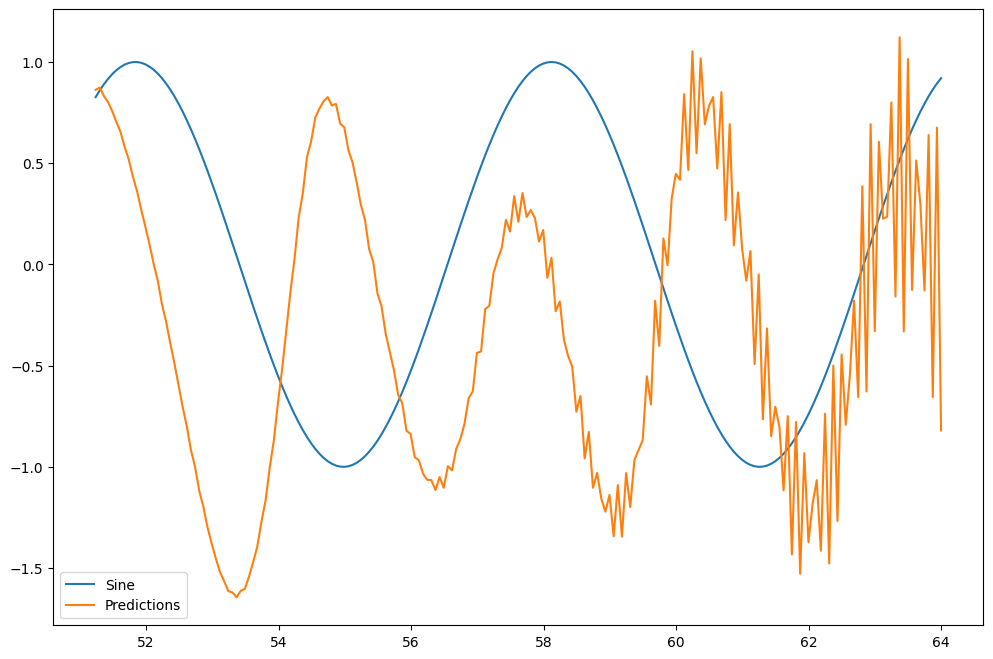

In [52]:
# visualize the updated data set
# Compare the predicted sine wave against the original sine wave

data_test.plot(figsize=(12,8))
